# AtmosAlert - Inteligência Espacial para Saúde Urbana

## Turma:1TSCOR 2025/2 
## Grupo: Data Insight
## Autores: 

|            Nome           |    RM    |
| ------------------------- | -------- |
| Daniela Pereira da Silva  | RM567079 |
| Fabio Ladislau do Amaral  | RM567292 |
| Regina Ferreira Bolsaneli | RM567828 |
| Thiago de Souza Perez     | RM568322 |
| Wagner Martins de Santana | RM567734 |

## Cenário
### Anualmente, a temporada de queimadas no Brasil gera plumas gigantescas de fumaça e aerossóis tóxicos que comprometem severamente a saúde pública. O problema crítico de gestão é que a poluição não respeita fronteiras municipais ou estaduais. Frequentemente, hospitais em grandes centros urbanos sofrem com a superlotação por problemas respiratórios agudos em dias onde não há um único foco de incêndio registrado no próprio município. O modelo tradicional de monitoramento público foca majoritariamente em olhar para os mapas de fogo ativo local, o que cria um "ponto cego" letal na prevenção de crises de saúde: a fumaça "invisível" que é transportada pelos ventos por milhares de quilômetros de distância.

## Solução
### O AtmosAlert é um sistema analítico preditivo desenhado para iluminar esse ponto cego. Através de um pipeline automatizado de Engenharia de Dados, nossa solução cruza informações de três painéis satelitais distintos (Foco de Fogo, Dinâmica de Ventos e Concentração de Aerossóis) para mapear o "efeito de latência" e o transporte das plumas de poluição. Aplicamos métodos estatísticos robustos de detecção de anomalias (Box-Plot/IQR e Z-Score) para substituir achismos por limiares matemáticos de perigo. O resultado é um motor de regras nacional que dispara alertas de risco à saúde (Alerta Laranja e Vermelho) baseados na qualidade do ar que efetivamente chegará à cidade, permitindo que a Defesa Civil e a infraestrutura hospitalar ajam preventivamente.

## ODSs Atendidas
### ODS 11 (Cidades Sustentáveis) e ODS 13 (Ação Contra a Mudança Global do Clima)

## Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pingouin as pg

## Origem e Dicionário de Dados
### O projeto orquestra a ingestão e consolidação de dados nacionais, monitorando os municípios de maior relevância nos 27 estados do Brasil (Agosto/2023). O dataset final unificado (df_atmosalert) é composto pelas seguintes fontes: 
### **Fonte 1: INPE (Programa Queimadas)**<br>Origem dos dados vetoriais de incêndios ativos reais.Variável Chave: `Focos_Calor` (Contagem diária agregada de incêndios dentro do polígono do município).
### **Fonte 2: NASA POWER (Prediction Of Worldwide Energy Resources)**<br>API global de clima que atua como o mapeador do "motor de transporte" da poluição.Variáveis Chave: `Velocidade_Vento_50m` (m/s) e `Direcao_Vento_50m` (Graus meteorológicos).
### **Fonte 2: Copernicus Sentinel-5P (Agência Espacial Europeia)**<br>Satélite focado exclusivamente na composição da atmosfera (Qualidade do ar). Variável Chave: `Indice_Fumaca` (Índice absorvente de aerossóis - UVAI), que quantifica a densidade real da fuligem tóxica suspensa sobre a cidade.

## Ingestão de Dados
### Carregamento de tabelas em dataframes para analise.

In [27]:
# Passando o caminho dos arquivos CSV
caminho_queimadas = '../data/raw/bdqueimadas_agosto_2023.csv'
caminho_fumaca = '../data/raw/fumaca_copernicus_agosto_2023.csv'
caminho_vento = '../data/raw/vento_nasa_agosto_2023.csv'

# Carregando os arquivos CSV em DataFrames
df_queimadas = pd.read_csv(caminho_queimadas)
df_fumaca = pd.read_csv(caminho_fumaca)
df_vento = pd.read_csv(caminho_vento)

# Validação do carregamento (linhas x colunas)
print(f"Queimadas (INPE): {df_queimadas.shape[0]} linhas e {df_queimadas.shape[1]} colunas.")
print(f"Fumaça (Copernicus): {df_fumaca.shape[0]} linhas e {df_fumaca.shape[1]} colunas.")
print(f"Vento (NASA): {df_vento.shape[0]} linhas e {df_vento.shape[1]} colunas.")

Queimadas (INPE): 5102 linhas e 10 colunas.
Fumaça (Copernicus): 798 linhas e 3 colunas.
Vento (NASA): 837 linhas e 4 colunas.


## Limpeza e Tratamento
### Verificação de valores nulos e tipo de dados das colunas.

In [4]:
# Verificação de valores ausentes e tipo dos dados no dataframe de queimadas
info_df_queimadas = pd.DataFrame({
    "coluna":       df_queimadas.dtypes.index,
    "dtype":        df_queimadas.dtypes.values.astype(str),
    "non_null":     df_queimadas.count().values,
    "nulos":        df_queimadas.isnull().sum().values,
    "nulos_%":      (df_queimadas.isnull().mean().values * 100).round(2),
})
info_df_queimadas.style\
    .format({"nulos_%": "{:.2f}%"})\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

,coluna,dtype,non_null,nulos,nulos_%
0,id_bdq,int64,5102,0,0.00%
1,foco_id,str,5102,0,0.00%
2,lat,float64,5102,0,0.00%
3,lon,float64,5102,0,0.00%
4,datahora,str,5102,0,0.00%
5,pais,str,5102,0,0.00%
6,estado,str,5102,0,0.00%
7,municipio,str,5102,0,0.00%
8,bioma,str,5102,0,0.00%
9,Data,str,5102,0,0.00%


In [5]:
# Verificação de valores ausentes e tipo dos dados no dataframe de ventos
info_df_vento = pd.DataFrame({
    "coluna":       df_vento.dtypes.index,
    "dtype":        df_vento.dtypes.values.astype(str),
    "non_null":     df_vento.count().values,
    "nulos":        df_vento.isnull().sum().values,
    "nulos_%":      (df_vento.isnull().mean().values * 100).round(2),
})
info_df_vento.style\
    .format({"nulos_%": "{:.2f}%"})\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

,coluna,dtype,non_null,nulos,nulos_%
0,Velocidade_Vento_50m,float64,837,0,0.00%
1,Direcao_Vento_50m,float64,837,0,0.00%
2,Data,str,837,0,0.00%
3,Municipio,str,837,0,0.00%


In [6]:
# Verificação de valores ausentes e tipo dos dados no dataframe de fumaça
info_df_fumaca = pd.DataFrame({
    "coluna":       df_fumaca.dtypes.index,
    "dtype":        df_fumaca.dtypes.values.astype(str),
    "non_null":     df_fumaca.count().values,
    "nulos":        df_fumaca.isnull().sum().values,
    "nulos_%":      (df_fumaca.isnull().mean().values * 100).round(2),
})
info_df_fumaca.style\
    .format({"nulos_%": "{:.2f}%"})\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

,coluna,dtype,non_null,nulos,nulos_%
0,Data,str,798,0,0.00%
1,Indice_Fumaca,float64,798,0,0.00%
2,Municipio,str,798,0,0.00%


## Tratamento de Datas
### Conversão de colunas de datas que estão com tipo string para formato datetime

In [7]:
# Conversões de dados(string para data)
df_queimadas['Data'] = pd.to_datetime(df_queimadas['Data'])
df_queimadas['datahora'] = pd.to_datetime(df_queimadas['datahora'])
df_fumaca['Data'] = pd.to_datetime(df_fumaca['Data'])
df_vento['Data'] = pd.to_datetime(df_vento['Data'])

# Padronizando o nome da coluna de município para bater com as outras bases
df_queimadas.rename(columns={'municipio': 'Municipio'}, inplace=True)

## Estatistica Descritiva
### Estatistica descritiva para cada um dos dataframes.

In [8]:
# Estatística Descritiva do dataframe de queimadas e concatenção no eixo das colunas (axis=1).
# Preenchimento de NaN onde não se aplica.
desc_queimadas = pd.concat([df_queimadas.describe(), df_queimadas.describe(include=['object'])], axis=1)

desc_queimadas.style\
    .format(precision=3, na_rep="—")\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

/tmp/ipykernel_6807/2459310105.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  desc_queimadas = pd.concat([df_queimadas.describe(), df_queimadas.describe(include=['object'])], axis=1)


,id_bdq,lat,lon,datahora,Data,foco_id,pais,estado,Municipio,bioma
count,5102.000,5102.000,5102.000,5102,5102,5102,5102,5102,5102,5102
mean,1644998359.488,-9.814,-57.746,2023-08-18 12:01:15.135241,2023-08-17 18:16:13.735790,—,—,—,—,—
min,1641478304.000,-29.524,-71.665,2023-08-01 16:35:00,2023-08-01 00:00:00,—,—,—,—,—
25%,1643790720.250,-9.444,-65.087,2023-08-12 17:43:00,2023-08-12 00:00:00,—,—,—,—,—
50%,1645207448.000,-8.674,-55.254,2023-08-19 17:41:00,2023-08-19 00:00:00,—,—,—,—,—
75%,1646125076.750,-7.399,-53.222,2023-08-23 18:51:00,2023-08-23 00:00:00,—,—,—,—,—
max,1647733821.000,4.544,-36.577,2023-08-31 17:56:00,2023-08-31 00:00:00,—,—,—,—,—
std,1605253.318,5.327,8.036,—,—,—,—,—,—,—
unique,—,—,—,—,—,5102,1,26,26,5
top,—,—,—,—,—,22f7296b-bbec-3181-a8c1-39df740b6bff,Brasil,PARÁ,ALTAMIRA,Amazônia


In [9]:
# Estatística Descritiva do dataframe de fumaça e concatenção no eixo das colunas (axis=1).
# Preenchimento de NaN onde não se aplica.
desc_fumaca = pd.concat([df_fumaca.describe(), df_fumaca.describe(include=['object'])], axis=1)

desc_fumaca.style\
    .format(precision=3, na_rep="—")\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

/tmp/ipykernel_6807/4135019938.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  desc_fumaca = pd.concat([df_fumaca.describe(), df_fumaca.describe(include=['object'])], axis=1)


,Data,Indice_Fumaca,Municipio
count,798,798.000,798
mean,2023-08-15 00:36:05.413533,-0.286,—
min,2023-08-01 00:00:00,-1.962,—
25%,2023-08-08 00:00:00,-0.678,—
50%,2023-08-15 00:00:00,-0.244,—
75%,2023-08-22 00:00:00,0.116,—
max,2023-08-29 00:00:00,1.817,—
std,—,0.599,—
unique,—,—,27
top,—,—,SAO FRANCISCO DE PAULA


In [10]:
# Estatística Descritiva do dataframe de vento e concatenção no eixo das colunas (axis=1).
# Preenchimento de NaN onde não se aplica.
desc_vento = pd.concat([df_vento.describe(), df_vento.describe(include=['object'])], axis=1)

desc_vento.style\
    .format(precision=3, na_rep="—")\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12px"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])

/tmp/ipykernel_6807/560714571.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  desc_vento = pd.concat([df_vento.describe(), df_vento.describe(include=['object'])], axis=1)


,Velocidade_Vento_50m,Direcao_Vento_50m,Data,Municipio
count,837.000,837.000,837,837
mean,4.541,121.926,2023-08-16 00:00:00,—
min,0.940,0.000,2023-08-01 00:00:00,—
25%,2.680,67.100,2023-08-08 00:00:00,—
50%,4.230,100.200,2023-08-16 00:00:00,—
75%,6.250,133.900,2023-08-24 00:00:00,—
max,10.550,359.400,2023-08-31 00:00:00,—
std,2.146,90.167,—,—
unique,—,—,—,27
top,—,—,—,FEIJO


## Junção dos DataFrames
### Aqui juntamos todos os dataframes em uma unica tabela de forma que possamos fazer uma analise unificada. Na tabela de queimadas foi feito agrupamento com contagem de focos de calor. Na tabela de fumaça foi feito detectado que por vezes o satélite tira duas fotos do mesmo município com dados bem próximos. A partir disso é feito um agupamento com a média do valor dos dados.

In [11]:
# Tratamento de duplicidades na base de Fumaça (Sentinel-5P)
# Tirei a média das leituras do satélite para garantir apenas 1 linha por dia/cidade(Em alguns casos o satélite tirou duas fotos do mesmo município no mesmo dia)
df_fumaca_tratado = (df_fumaca
                     .groupby(['Data', 'Municipio'], as_index=False)
                     .agg({'Indice_Fumaca': 'mean'}))

# Agrupamento dos focos do INPE
# Conta a quantidade de focos (linhas) para cada combinação de dia e cidade
df_queimadas_agrupado = (df_queimadas
                         .groupby(['Data', 'Municipio'])
                         .size()
                         .reset_index(name='Focos_Calor'))

# União das duas tabelas que já possuem registos diários (usando a fumaça tratada)
df_consolidado = pd.merge(df_fumaca_tratado, df_vento, on=['Data', 'Municipio'], how='inner')

# Adição dos focos de calor agrupados usando 'left' 
df_atmosalert = pd.merge(df_consolidado, df_queimadas_agrupado, on=['Data', 'Municipio'], how='left')

# Tratamento de nulos
# Se a união gerou valores nulos (NaN) em Focos_Calor, significa que não houve fogo.
# Substituímos por 0 e convertemos para número inteiro.
df_atmosalert['Focos_Calor'] = df_atmosalert['Focos_Calor'].fillna(0).astype(int)

# Ordenação final para manter a linha do tempo organizada
df_atmosalert = df_atmosalert.sort_values(by=['Municipio', 'Data']).reset_index(drop=True)

print(f"Tratamento concluído! Total de registos gerados: {df_atmosalert.shape[0]} linhas.")

# Validação da estrutura final
print("Estrutura do novo DataFrame unificado:")
#df_atmosalert.info()
display(df_atmosalert.head(10))

Tratamento concluído! Total de registos gerados: 776 linhas.
Estrutura do novo DataFrame unificado:


,Data,Municipio,Indice_Fumaca,Velocidade_Vento_50m,Direcao_Vento_50m,Focos_Calor
0,2023-08-01,ALTAMIRA,-1.077591,2.54,50.0,0
1,2023-08-02,ALTAMIRA,-0.678123,2.46,59.4,31
2,2023-08-03,ALTAMIRA,-0.107790,2.50,60.9,6
3,2023-08-04,ALTAMIRA,-0.501449,2.46,57.8,19
4,2023-08-05,ALTAMIRA,-1.313093,2.66,60.9,14
5,2023-08-06,ALTAMIRA,-0.825194,2.90,68.8,6
6,2023-08-07,ALTAMIRA,-0.592765,2.82,58.2,33
7,2023-08-08,ALTAMIRA,0.032284,2.60,62.8,6
8,2023-08-09,ALTAMIRA,-0.715192,2.73,51.9,86
9,2023-08-10,ALTAMIRA,-0.793383,2.96,58.6,2


## Detecção de outliers
### Neste bloco nós estabelecemos os gatilhos matemáticos para os alertas de saúde pública do AtmosAlert. Nós evitamos usar valores arbitrários definidos por nós; em vez disso, deixamos a própria distribuição nacional dos dados ditar o que constitui uma crise, utilizando duas réguas estatísticas distintas:
### **O Método IQR (Alerta Laranja)**: O Box-Plot foi utilizado para identificar dias que escapam do padrão interquartil daquela região. A vantagem matemática do IQR é que ele é robusto contra valores extremos. O limite superior que calculamos `(Q3 + 1.5 * IQR)` serve como nosso nível de atenção. Ele indica que a poluição já quebrou o padrão normal e a saúde da população começa a ser impactada.
### **O Score Z (Alerta Vermelho)**: Para classificar os eventos catastróficos, implementamos o Z-Score. Ele mede a quantos desvios padrões um dia específico está da média nacional de fumaça. Ao definirmos o limite de `Z > 3`, estamos focando na cauda extrema da curva normal (estatisticamente, eventos que têm menos de 0,3% de probabilidade de ocorrer no padrão habitual). Este é o nosso gatilho de emergência máxima, indicando dias como aquele de Porto Velho, onde a fumaça atingiu níveis asfixiantes.

In [29]:
# Box-Plot (IQR)
# Calculando os Quartis (Q1 e Q3) da Fumaça
Q1 = df_atmosalert['Indice_Fumaca'].quantile(0.25)
Q3 = df_atmosalert['Indice_Fumaca'].quantile(0.75)
IQR = Q3 - Q1

# Definindo o Limite Superior de Alerta
limite_superior_iqr = Q3 + 1.5 * IQR

# Criando a coluna de alerta (True se for maior que o limite)
df_atmosalert['Alerta_IQR'] = df_atmosalert['Indice_Fumaca'] > limite_superior_iqr

# Score Z
# Calculando a média e o desvio padrão da Fumaça
media_fumaca = df_atmosalert['Indice_Fumaca'].mean()
std_fumaca = df_atmosalert['Indice_Fumaca'].std()

# Calculando o Score Z para cada registro e guardando em uma nova coluna
df_atmosalert['Score_Z_Fumaca'] = (df_atmosalert['Indice_Fumaca'] - media_fumaca) / std_fumaca

# Definindo o Limite de Alerta Extremo (Z > 3)
limite_z = 3.0

# Criando a coluna de alerta baseada no Score Z
df_atmosalert['Alerta_Z'] = df_atmosalert['Score_Z_Fumaca'] > limite_z

# Resumo Estatístico dos Alertas
dias_alerta_iqr = df_atmosalert['Alerta_IQR'].sum()
dias_alerta_z = df_atmosalert['Alerta_Z'].sum()

print("\n--- LIMIARES MATEMÁTICOS ---")
print(f"Média de Fumaça no Brasil (Agosto/23): {media_fumaca:.3f}")
print(f"Limite Box-Plot (IQR): Fumaça > {limite_superior_iqr:.3f}")
print(f"Limite Score Z (>3): Fumaça > {(media_fumaca + (3 * std_fumaca)):.3f}")

print("\n--- IMPACTO DETECTADO ---")
print(f"Dias classificados como ALERTA LARANJA (IQR): {dias_alerta_iqr} dias.")
print(f"Dias classificados como ALERTA VERMELHO (Score Z): {dias_alerta_z} dias.")

# Mostrando uma amostra apenas dos dias que deram Alerta Vermelho
print("\n🔍 Amostra do pior dia registrado (Alerta Vermelho):")
display(df_atmosalert[df_atmosalert['Alerta_Z'] == True].sort_values(by='Indice_Fumaca', ascending=False).head(5))


--- LIMIARES MATEMÁTICOS ---
Média de Fumaça no Brasil (Agosto/23): -0.296
Limite Box-Plot (IQR): Fumaça > 1.245
Limite Score Z (>3): Fumaça > 1.438

--- IMPACTO DETECTADO ---
Dias classificados como ALERTA LARANJA (IQR): 5 dias.
Dias classificados como ALERTA VERMELHO (Score Z): 1 dias.

🔍 Amostra do pior dia registrado (Alerta Vermelho):


,Data,Municipio,Indice_Fumaca,Velocidade_Vento_50m,Direcao_Vento_50m,Focos_Calor,Alerta_IQR,Score_Z_Fumaca,Alerta_Z
563,2023-08-16,PORTO VELHO,1.816792,1.59,304.4,0,True,3.655559,True


## Investigação

### É possível verificar que um dos piores dias é 16/08/2023, porém não há registro de focos de calor nesse dia.
### No dia 12, houve 19 focos de incêndio e, no dia 15 (véspera do alerta), o satélite registrou mais 17 focos. Ou seja, a região estava queimando e gerando toneladas de aerossóis. Porém, o Índice de Fumaça no dia 15 ainda estava em -0.05 (normal). O vento estava batendo a 216 graus (Sudoeste). Ele estava literalmente levando a fumaça para longe do centro urbano de Porto Velho. No dia 16 a direção do vento girou para 304.4 graus (Noroeste). O vento mudou de sentido e começou a trazer toda aquela fumaça que estava acumulada na floresta direto para cima da cidade. A velocidade baixa do vento (1.59) ajudou essa nuvem a estacionar.<br>O Índice de Fumaça salta para 1.81. A cidade acorda coberta de fuligem, sem um único foco de incêndio ativo no seu território naquele momento.

In [ ]:
# Definindo os parâmetros da investigação
cidade_alvo = 'PORTO VELHO'
data_pico = pd.to_datetime('2023-08-16')
dias_para_voltar = 5

# Calculando a data de início (5 dias antes)
data_inicio = data_pico - pd.Timedelta(days=dias_para_voltar)

# Filtrando o DataFrame para pegar apenas essa cidade e essa janela de tempo
df_investigacao = df_atmosalert[
    (df_atmosalert['Municipio'] == cidade_alvo) & 
    (df_atmosalert['Data'] >= data_inicio) & 
    (df_atmosalert['Data'] <= data_pico)
]

# Selecionando apenas as colunas essenciais para não poluir a tela
colunas_foco = ['Data', 'Municipio', 'Focos_Calor', 'Indice_Fumaca', 'Velocidade_Vento_50m', 'Direcao_Vento_50m']

# Exibindo o resultado
print(f"Investigando o histórico de {cidade_alvo} entre {data_inicio.strftime('%d/%m/%Y')} e {data_pico.strftime('%d/%m/%Y')}.")
display(df_investigacao[colunas_foco])

Investigando o histórico de PORTO VELHO entre 11/08/2023 e 16/08/2023.


,Data,Municipio,Focos_Calor,Indice_Fumaca,Velocidade_Vento_50m,Direcao_Vento_50m
558,2023-08-11,PORTO VELHO,1,-0.051991,1.59,9.7
559,2023-08-12,PORTO VELHO,19,-0.313020,1.54,289.0
560,2023-08-13,PORTO VELHO,0,-0.144400,2.17,165.9
561,2023-08-14,PORTO VELHO,0,-1.465844,1.94,195.8
562,2023-08-15,PORTO VELHO,17,-0.053410,1.79,216.6
563,2023-08-16,PORTO VELHO,0,1.816792,1.59,304.4


## Visualizações

### A Análise Univariada (O Box-Plot à esquerda): O objetivo aqui foi isolar o nosso Índice de Fumaça e encontrar a régua matemática do perigo.A caixa cinza representa a massa de dados normais (a grande maioria dos dias do mês).As bolinhas amarelas que saltam para o topo são as anomalias detectadas pelo método **Intervalo Interquartil (IQR)**. Nós calculamos esse limite estatisticamente e traçamos uma linha de corte.  A linha vermelha tracejada é o nosso limite extremo, o **Score Z > 3**. Qualquer ponto acima dessa linha representa um evento catastrófico de poluição. Isso prova que o sistema consegue identificar matematicamente os dias fora da curva.

### A Análise Bivariada (A Dispersão à direita): Aqui nós cruzamos a fumaça com a nossa variável exógena principal: o Vento. Ao colorir os pontos com a mesma lógica do Box-Plot (amarelo para alertas), nós provamos a teoria de negócio do AtmosAlert. A nuvem amarela (dias de alerta) está majoritariamente deslocada para a direita, ou seja, nos dias em que o vento estava mais forte. A linha de corte laranja, calculada pelo IQR, separa visualmente o que é um dia normal de um dia em que a fumaça estacionou ou foi trazida pelo vento, justificando o cruzamento das APIs."

/tmp/ipykernel_6807/268319753.py:55: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  axes[1].legend(handles=handles, labels=['Dia Normal', 'Dia de Alerta'], title='Status AtmosAlert')


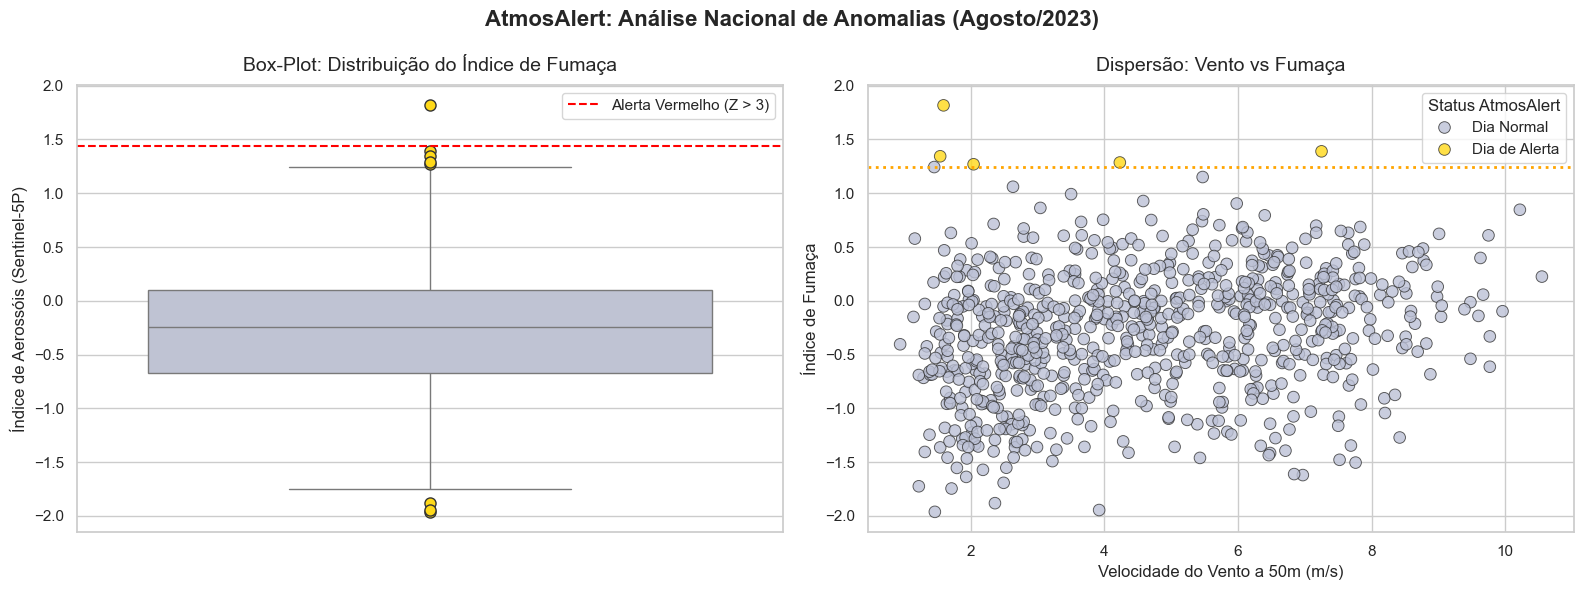

In [14]:
# Configuração de estilo e paleta de cores
sns.set_theme(style="whitegrid")
cor_base = '#BCC1D6'     # Cinza suave para os dias normais
cor_alerta = '#FFD919'   # Amarelo alerta para os outliers

# Criando uma figura com 2 gráficos (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AtmosAlert: Análise Nacional de Anomalias (Agosto/2023)', fontsize=16, fontweight='bold')

# Gráfico 1: O Box-Plot (Visão Univariada)
sns.boxplot(
    ax=axes[0],
    y=df_atmosalert['Indice_Fumaca'], 
    color=cor_base, 
    flierprops={
        'marker': 'o', 
        'markerfacecolor': cor_alerta, 
        'markeredgecolor': '#333333',
        'markersize': 8
    }
)

# Recalculando limites só para desenhar as linhas no gráfico
media = df_atmosalert['Indice_Fumaca'].mean()
std = df_atmosalert['Indice_Fumaca'].std()
limite_z_grafico = media + (3 * std)
limite_iqr_grafico = df_atmosalert['Indice_Fumaca'].quantile(0.75) + 1.5 * (df_atmosalert['Indice_Fumaca'].quantile(0.75) - df_atmosalert['Indice_Fumaca'].quantile(0.25))

axes[0].axhline(limite_z_grafico, color='red', linestyle='--', linewidth=1.5, label='Alerta Vermelho (Z > 3)')
axes[0].set_title('Box-Plot: Distribuição do Índice de Fumaça', fontsize=14, pad=10)
axes[0].set_ylabel('Índice de Aerossóis (Sentinel-5P)')
axes[0].legend()

# Gráfico 2: Dispersão Vento vs Fumaça (Visão Bivariada)
# Colorindo os pontos baseados na coluna de Alerta_IQR que criamos antes
sns.scatterplot(
    ax=axes[1],
    data=df_atmosalert,
    x='Velocidade_Vento_50m',
    y='Indice_Fumaca',
    hue='Alerta_IQR',
    palette={False: cor_base, True: cor_alerta},
    edgecolor='#333333',
    s=70, # Tamanho dos círculos
    alpha=0.8
)

axes[1].axhline(limite_iqr_grafico, color='orange', linestyle=':', linewidth=2, label='Linha de Corte (IQR)')
axes[1].set_title('Dispersão: Vento vs Fumaça', fontsize=14, pad=10)
axes[1].set_xlabel('Velocidade do Vento a 50m (m/s)')
axes[1].set_ylabel('Índice de Fumaça')

# Ajusta a legenda para ficar clara para quem não é técnico
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=['Dia Normal', 'Dia de Alerta'], title='Status AtmosAlert')

# Ajusta o layout e plota
plt.tight_layout()
plt.show()

## Correlação
### Fogo x Fumaça, 0.04 é uma correlação "Nenhuma" ou "Negligenciável". Ou seja, matematicamente, ter um foco de incêndio dentro dos limites de uma cidade tem impacto quase zero na quantidade de fumaça que está no céu daquela mesma cidade no mesmo dia.

### Vento x Fumaça, 0.26 indica que, de forma geral, quando a velocidade do vento sobe, o índice de fumaça também tende a subir nas cidades analisadas. O vento atua como o motor que importa a fuligem de outros lugares. O vento explica muito mais a poluição (0.26) do que o próprio fogo local (0.04).

### Vento x Fogo, -0,33 indica uma correlação negativa "Fraca" a "Moderada". Isso significa que dias com ventanias mais fortes tendem a ter menos focos de calor registrados localmente (ou o vento espalha o calor dificultando a leitura infravermelha do satélite, ou frentes frias com ventos fortes trazem umidade que diminui o fogo).

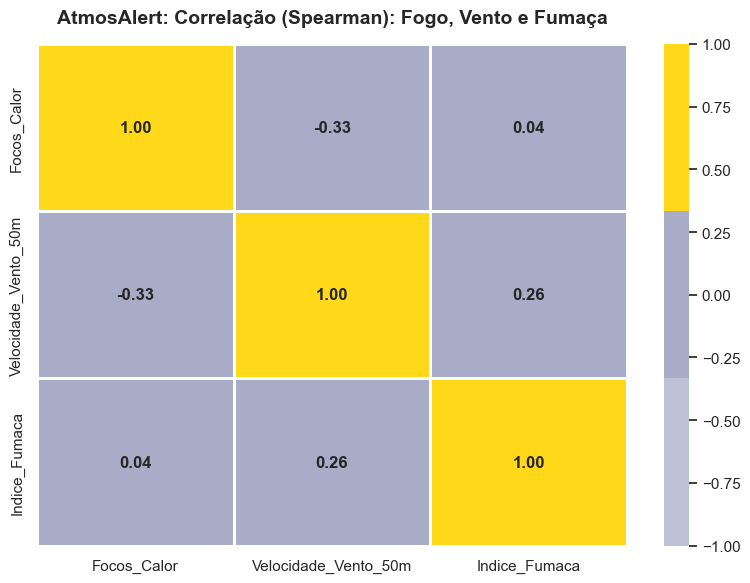

In [25]:
# 1. Selecionando apenas as variáveis numéricas contínuas
colunas_continuas = ['Focos_Calor', 'Velocidade_Vento_50m', 'Indice_Fumaca']
df_numerico = df_atmosalert[colunas_continuas]

# 2. Calculando a correlação de Spearman (ideal para dados com outliers como o nosso)
matriz_correlacao = df_numerico.corr(method='spearman')

# 3. Plotando a matriz com a paleta executiva
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# Usando tons de cinza e amarelo alerta
sns.heatmap(
    matriz_correlacao, 
    annot=True,              # Mostra os números dentro dos quadrados
    cmap=['#BCC1D6', '#A9ACC7', '#FFD919'], # Nossa paleta
    vmin=-1, vmax=1,         # A escala da correlação vai de -1 a 1
    linewidths=1, 
    linecolor='white',
    fmt=".2f",               # Duas casas decimais
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('AtmosAlert: Correlação (Spearman): Fogo, Vento e Fumaça', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Tabela de significancia estatística.
### Para garantir a validade das correlações encontradas na análise bivariada, aplicamos um teste de correlação de postos de Spearman. A escolha do método se justifica pela não normalidade esperada em eventos climáticos extremos (outliers).A tabela resultante foca em três pilares comprobatórios:O Coeficiente ($r$), que mede a intensidade da relação monotônica.O Intervalo de Confiança (CI95), atestando a estabilidade da métrica.O P-Value, rejeitando a hipótese nula ($H_0: \rho = 0$) para valores < 0.05 e cravando a significância estatística das nossas descobertas sobre o transporte de poluição.

In [26]:
# Definindo as colunas que queremos analisar
colunas_alvo = ['Focos_Calor', 'Velocidade_Vento_50m', 'Indice_Fumaca']

# Rodando o teste pairwise com a matriz completa
teste_estatistico = pg.pairwise_corr(
    df_atmosalert, 
    columns=colunas_alvo, 
    method='spearman'
)

# Selecionando exatamente as colunas que a sua versão gerou
colunas_finais = ['X', 'Y', 'method', 'n', 'r', 'CI95', 'p_unc']
tabela_executiva = teste_estatistico[colunas_finais].copy()

# Renomeando as colunas para um formato de apresentação (Pitch)
tabela_executiva = tabela_executiva.rename(columns={
    'method': 'Método',
    'n': 'Amostra (Dias)',
    'r': 'Correlação (Spearman)',
    'CI95': 'Intervalo de Confiança (95%)',
    'p_unc': 'P-Value'
})

# Exibindo o resultado polido
print("Tabela de Significância Estatística.")
display(tabela_executiva)

Tabela de Significância Estatística.


,X,Y,Método,Amostra (Dias),Correlação (Spearman),Intervalo de Confiança (95%),P-Value
0,Focos_Calor,Velocidade_Vento_50m,spearman,776,-0.328739,"[-0.39, -0.26]",5.178327e-21
1,Focos_Calor,Indice_Fumaca,spearman,776,0.041143,"[-0.03, 0.11]",2.523143e-01
2,Velocidade_Vento_50m,Indice_Fumaca,spearman,776,0.257299,"[0.19, 0.32]",3.366691e-13


## Conclusões e Impacto para Tomada de Decisão

### As análises bivariadas e os testes de significância estatística (Spearman) aplicados no AtmosAlert desconstruíram um paradigma perigoso da gestão pública: **o fogo local não explica a fumaça local (Correlação de apenas 0.04, estatisticamente descartável)**.A matemática atestou que a verdadeira causa do sufocamento urbano é a dinâmica do vento, que atua como uma "esteira rolante" interstadual de poluição **(Correlação Vento x Fumaça de 0.26, com P-Value de $3.36 \times 10^{-13}$**, provando que não é obra do acaso). Essa descoberta explica as anomalias do modelo (Z-Score > 3), como o caso de Porto Velho (16/08/2023), que registrou o ápice do Índice de Fumaça (1.81) em um dia com zero focos de calor, puramente por conta de uma virada brusca nos ventos que trouxe uma pluma estacionada de regiões vizinhas.

### **Impactos Diretos para Tomada de Decisão (Negócio)**:<br> **1. Otimização de Leitos e Plantões**: Secretarias de Saúde ganham previsibilidade. Ao cruzar o vento forte com incêndios distantes, o sistema alerta para o risco respiratório antes de a fumaça cobrir a cidade, otimizando plantões médicos e o estoque de insumos de oxigênio.<br> **2. Alocação de Recursos (Defesa Civil):**: Prova-se que apagar o fogo municipal não salva a cidade da fumaça se estados vizinhos continuarem queimando. A gestão de crise deve ser tratada como um esforço logístico macro-regional.<br> **3. Maturidade e Escalabilidade Tecnológica:**: O pipeline de dados consolidado trata duplicidades de satélites automaticamente. Os outputs gerados (Status de Alerta IQR/Z-Score) estão perfeitamente modelados para consumo imediato por qualquer dashboard.

## Link do protótipo web
·	Inserir aqui o link do protótipo web.